In [2]:
import os
os.environ['DATASET_DIR']='data'


In [3]:
!pip install torch
!pip install einops


import abc
import torch
import numpy as np
from torch.utils.data import Dataset
from typing import Optional, Sequence, List
from torch.utils.data import Dataset, Subset
from torch import default_generator, randperm
from einops import rearrange

In [ ]:
from datasets.rearrange_dset import load_rearrange_slice_train_val

datasets, traj_dset = load_rearrange_slice_train_val(transform=None, n_rollout=5, num_hist=3, num_pred=1,data_path='/Users/julianquast/Documents/Bachelor Thesis/Datasets/rearrange_1k')
sample = datasets['train'][0]
obs, act, state = sample
print('visual shape:', obs['visual'].shape)
print('proprio shape:', obs['proprio'].shape)
print('action shape:', act.shape)
print('state shape:', state.shape)

from torch.utils.data import DataLoader
loader = DataLoader(datasets['train'], batch_size=32)
batch_obs, batch_act, batch_state = next(iter(loader))
print('batch visual shape:', batch_obs['visual'].shape)
print('batch proprio shape:', batch_obs['proprio'].shape)
print('batch action shape:', batch_act.shape)
print('batch state shape:', batch_state.shape)

visual shape: torch.Size([3, 3, 224, 224])
proprio shape: torch.Size([3, 1])
action shape: torch.Size([3, 1])
state shape: torch.Size([3, 1])
batch visual shape: torch.Size([32, 3, 3, 224, 224])
batch proprio shape: torch.Size([32, 3, 1])
batch action shape: torch.Size([32, 3, 1])
batch state shape: torch.Size([32, 3, 1])


Proprioceptive readings:
 tensor([[0.],
        [0.],
        [0.]])

Actions:
 tensor([[0.],
        [0.],
        [0.]])

States:
 tensor([[0.],
        [0.],
        [0.]])


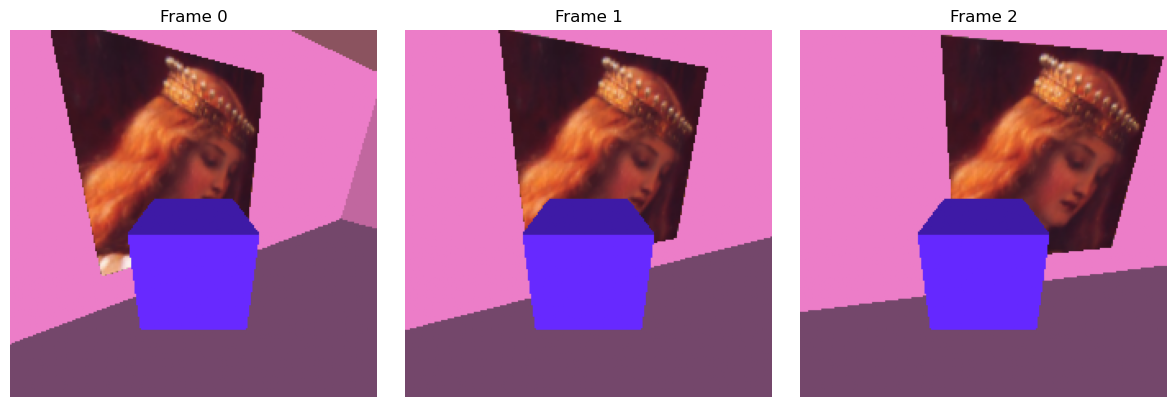


Combined table:
    proprio  action  state
0      0.0     0.0    0.0
1      0.0     0.0    0.0
2      0.0     0.0    0.0


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# — assume you already have obs, act, state from
#     obs, act, state = datasets['train'][0]

# 1) Print out the raw proprio/action/state values:
print("Proprioceptive readings:\n", obs['proprio'])
print("\nActions:\n", act)
print("\nStates:\n", state)

# 2) Visualize the 3 RGB image frames
#    obs['visual'] is a tensor of shape [3, 3, 224, 224]
visual = obs['visual'].cpu().numpy()   # to HWC below

fig, axes = plt.subplots(1, visual.shape[0], figsize=(12, 4))
for i in range(visual.shape[0]):
    img = visual[i].transpose(1, 2, 0)  # C,H,W -> H,W,C
    axes[i].imshow(img)
    axes[i].set_title(f"Frame {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

# 3) Combine proprio, action, state into a small table
df = pd.DataFrame({
    "proprio": obs['proprio'].cpu().numpy().flatten(),
    "action": act.cpu().numpy().flatten(),
    "state": state.cpu().numpy().flatten()
})
print("\nCombined table:\n", df)


First non-zero action indices: [1, 2, 3, 5, 6]

=== Snippet idx=1 ===
 Actions:
 tensor([[2.],
        [2.],
        [2.]])
 States:
 tensor([[0.],
        [0.],
        [0.]])
 Proprio:
 tensor([[0.],
        [0.],
        [0.]])


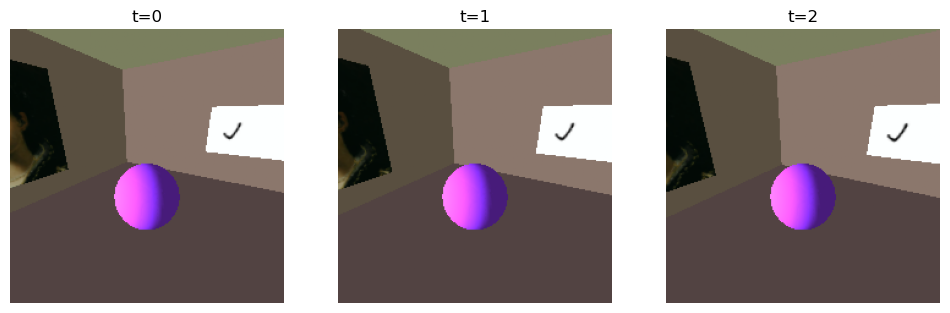


=== Snippet idx=2 ===
 Actions:
 tensor([[2.],
        [2.],
        [2.]])
 States:
 tensor([[0.],
        [0.],
        [0.]])
 Proprio:
 tensor([[0.],
        [0.],
        [0.]])


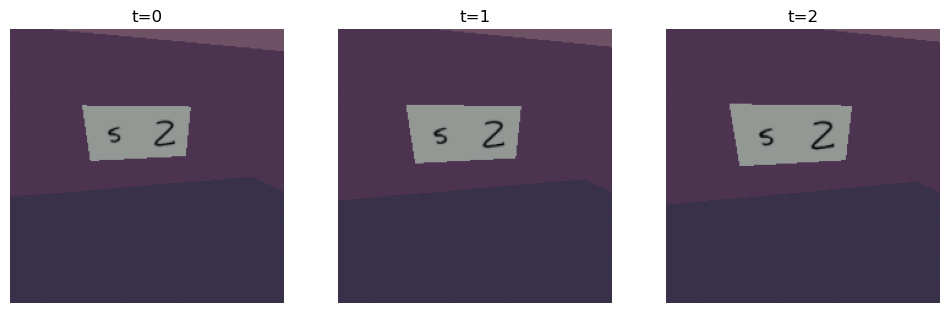


=== Snippet idx=3 ===
 Actions:
 tensor([[2.],
        [2.],
        [1.]])
 States:
 tensor([[0.],
        [0.],
        [0.]])
 Proprio:
 tensor([[0.],
        [0.],
        [0.]])


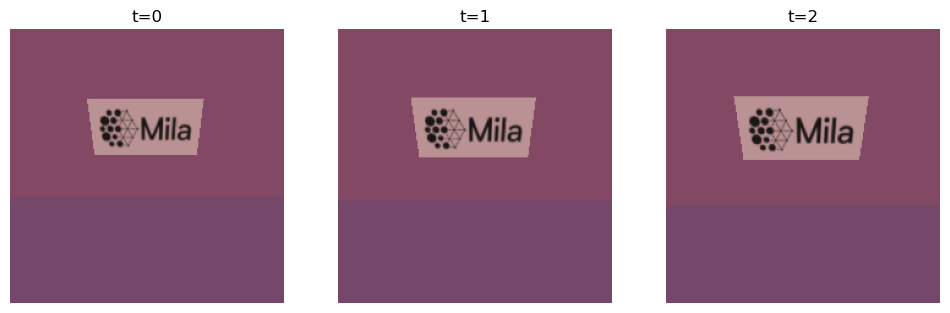


=== Snippet idx=5 ===
 Actions:
 tensor([[1.],
        [1.],
        [1.]])
 States:
 tensor([[0.],
        [0.],
        [0.]])
 Proprio:
 tensor([[0.],
        [0.],
        [0.]])


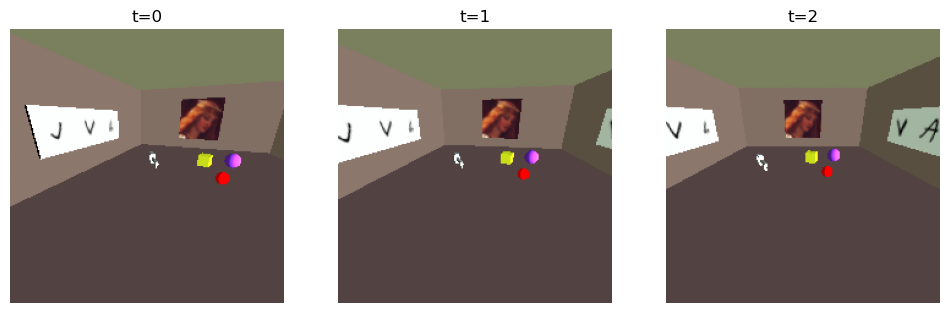


=== Snippet idx=6 ===
 Actions:
 tensor([[0.],
        [2.],
        [2.]])
 States:
 tensor([[0.],
        [0.],
        [0.]])
 Proprio:
 tensor([[0.],
        [0.],
        [0.]])


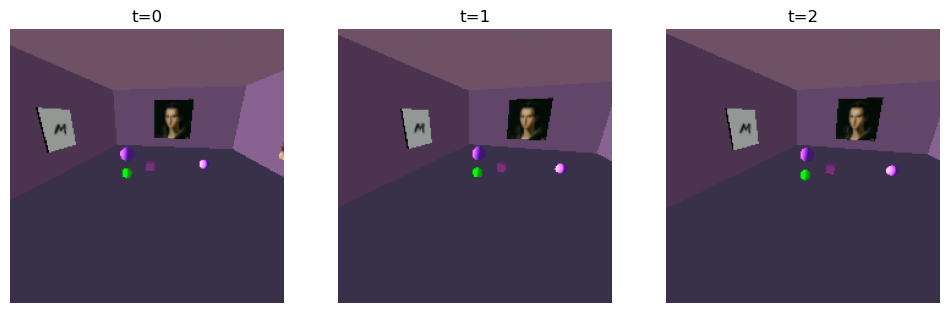

In [8]:
#import matplotlib.pyplot as plt

# 1) Find the first few non-zero snippets
train_ds = datasets['train']
nonzero = []
for idx in range(len(train_ds)):
    _, act, _ = train_ds[idx]
    if act.abs().sum().item() > 0:
        nonzero.append(idx)
    if len(nonzero) >= 5:
        break

print("First non-zero action indices:", nonzero)

# 2) For each, print the actions and plot the 3 frames
for idx in nonzero:
    obs, act, state = train_ds[idx]
    print(f"\n=== Snippet idx={idx} ===")
    print(" Actions:\n", act)
    print(" States:\n", state)
    print(" Proprio:\n", obs['proprio'])

    # Visualize the RGB frames
    visual = obs['visual'].cpu().numpy()  # [3,3,224,224]
    fig, axes = plt.subplots(1, visual.shape[0], figsize=(12,4))
    for t in range(visual.shape[0]):
        img = visual[t].transpose(1,2,0)
        axes[t].imshow(img)
        axes[t].set_title(f"t={t}")
        axes[t].axis("off")
    plt.show()
